# Threshold and Precision/Recall

We analyze the **breakpoint phenomenon** when choosing binarization thresholds for continuous anomaly score maps.

## Why this is Crucial

Anomaly localization models output a continuous score per pixel. 
To deploy this in a factory, we must choose a cutoff threshold. 
Choosing the threshold is a business decision: 

- Higher threshold $\rightarrow$ High Precision (fewer false alarms, but some defects missed).
- Lower threshold $\rightarrow$ High Recall (catches all defects, but line stops frequently for false alarms).

## Optimization: Maximum $F_{\beta}$ Score

We compute $F_1$ (balanced), $F_2$ (recall-heavy), and $F_{0.5}$ (precision-heavy) to determine the mathematically optimal thresholds.

## How do we proceed?

We start by checking the image and pixel-level class imbalances for our chosen category, to emphasize that the AUPR for our dataset is absolutely paramount to assess model qualities.
Afterwards, we check out the pixel-level imbalances in all categories and compare them using boxplots.
Afterwards, we check what benchmarks are provided and how we can use them. To achieve our results and evaluate them within the bounds of this project.

## Pixel-Level Class Imbalance in Anomaly Detection

Before analyzing threshold trade offs, we must understand the structure of the MVTec AD dataset. 
In anomaly localization (pixel-level detection), accuracy is a highly deceptive metric.
This is because of an extreme class imbalance:

- Image-level: The test set might have many anomalous images to test defect capture.
- Pixel-level: Even on anomalous images, the defect covers only a tiny fraction of the total surface area. The vast majority of pixels remain normal background.

Below, we compute and visualize the image-level vs. pixel-level class distributions in the test set. Emphasizing the importance of Precision, Recall, and especially AUPR instead of Accuracy.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.stats as stats
from PIL import Image

# Global Data Path Configurations
MVTEC_BASE_DIR = Path("../../data/raw/mvtec_ad")
BOTTLE_DIR = MVTEC_BASE_DIR / "bottle"

def get_anomaly_pixels(img_path, base_dir=BOTTLE_DIR):
    """Calculates the total number of anomalous pixels from a mask file."""
    # stem -> final path component without suffix
    mask_path = base_dir / "ground_truth" / img_path.parent.name / f"{img_path.stem}_mask.png"
    return np.sum(np.array(Image.open(mask_path)) > 0) if mask_path.exists() else 0.0

In [78]:
# 1. Gather Image Path Lists
normal_imgs = list((BOTTLE_DIR / "test/good").glob("*.png"))
anomalous_imgs = [p for p in (BOTTLE_DIR / "test").glob("*/*.png") if p.parent.name != "good"]
train_imgs = list((BOTTLE_DIR / "train/good").glob("*.png"))

# 2. Process Volumes and Pixels
total_pixels = sum(np.prod(Image.open(p).size) for p in normal_imgs + anomalous_imgs)
total_anomalous_pixels = sum(get_anomaly_pixels(p, BOTTLE_DIR) for p in anomalous_imgs)
total_normal_pixels = total_pixels - total_anomalous_pixels

# 3. Print Results
print(f"Train Images: {len(train_imgs)} Normal")
print(f"Test Images: {len(normal_imgs)} Normal vs. {len(anomalous_imgs)} Anomalous")
print(f"Test Pixels: {total_normal_pixels:,} Normal vs. {total_anomalous_pixels:,} Anomalous")
print(f"Pixel-level Anomaly Ratio: {(total_anomalous_pixels / total_pixels) * 100:.4f}%")


Train Images: 209 Normal
Test Images: 20 Normal vs. 63 Anomalous
Test Pixels: 63,343,269 Normal vs. 3,886,731 Anomalous
Pixel-level Anomaly Ratio: 5.7812%


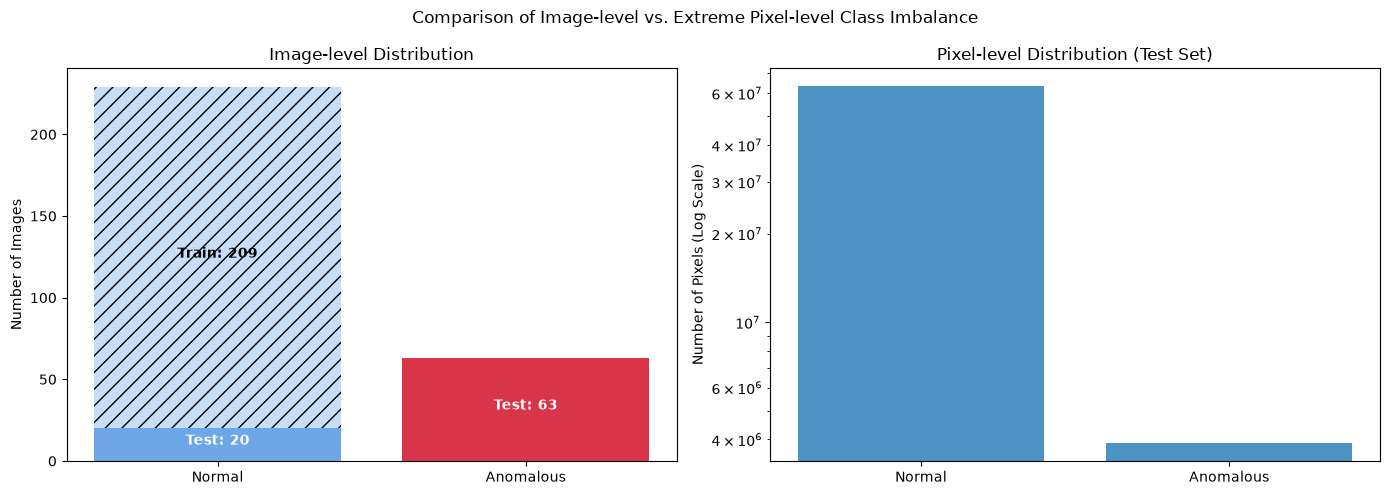

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# 1. Image-level Distribution (with half-transparent Train Set stacked on top of Normal Test Set)
plt.subplot(1, 2, 1)
plt.bar(["Normal", "Anomalous"], [num_normal, num_anomalous], color=["#4A90E2", "#D0021B"], alpha=0.8)
plt.bar(["Normal"], [num_train], bottom=[num_normal], color="#4A90E2", alpha=0.3, hatch="//")
plt.ylabel("Number of Images")
plt.title("Image-level Distribution")

# Add text labels
plt.text(0, num_normal/2, f"Test: {num_normal}", ha="center", color="white", fontweight="bold")
plt.text(0, num_normal + num_train/2, f"Train: {num_train}", ha="center", color="black", fontweight="bold")
plt.text(1, num_anomalous/2, f"Test: {num_anomalous}", ha="center", color="white", fontweight="bold")

# 2. Pixel-level Distribution
plt.subplot(1, 2, 2)
plt.bar(["Normal", "Anomalous"], [total_normal_pixels, total_anomalous_pixels], alpha=0.8)
plt.yscale("log")
plt.ylabel("Number of Pixels (Log Scale)")
plt.title("Pixel-level Distribution (Test Set)")

plt.suptitle("Comparison of Image-level vs. Extreme Pixel-level Class Imbalance")
plt.tight_layout()
plt.show()

                        1. What is your Goal?
                       /                     \
              Compare Groups              Find Relationships
                   /                               \
      2. What Data Type is the Outcome?     2. What Data Type are the Variables?
          /               \                      /                \
      Categorical       Continuous          Categorical         Continuous
         /                 \                    /                    \
    [Chi-Square]     3. How many groups?   [Chi-Square]      [Correlation/
                      /           \         (Independence)    Regression]
                    2 Groups     3+ Groups
                      /               \
                [t-test /        [ANOVA / 
             Mann-Whitney]    Kruskal-Wallis]


## Cross-Category Anomaly Ratio Variance & Kruskal-Wallis Test

While we established that the dataset is highly imbalanced at the pixel level on average, different physical categories present completely different defect size distributions.

To prove this statistically, we perform two analyses:

1. Kruskal-Wallis H-Test: We test the Null Hypothesis that the population medians of the image-level defect ratios are equal across all 15 categories. We choose the Kruskal-Wallis test over a pixel-level Chi-Square test because:

   * Pixels are highly spatially correlated (violating the independence assumption required for Chi-Square).
   * The massive pixel sample size ($N > 67$ million) artificially inflates the Chi-Square power, causing even trivial, microscopic differences to appear statistically significant.
   * The Kruskal-Wallis test treats each anomalous image ($N=63$) as a single independent observation, making the statistical test trustworthy.

2. **Cross-Category Boxplot:** We plot the distribution of anomaly pixel ratios (defect area / image area) for each individual anomalous image across the 15 categories to visualize the physical variance in defect sizes.

In [80]:
categories = sorted([d.name for d in mvtec_base_dir.iterdir() if d.is_dir() and not d.name.startswith(".") and d.name != "license.txt"])

all_ratios = []
for cat in categories:
    img_paths = [p for p in (MVTEC_BASE_DIR / cat / "test").glob("**/*.png") if p.parent.name != "good"]
    for p in img_paths:
        anom = get_anomaly_pixels(p, base_dir=MVTEC_BASE_DIR / cat)
        all_ratios.append({"Category": cat, "Ratio": anom / np.prod(Image.open(p).size)})

df_ratios = pd.DataFrame(all_ratios)

# Run Kruskal-Wallis H-test on image-level ratios (independent samples)
groups = [grp["Ratio"].values for _, grp in df_ratios.groupby("Category")]
res = stats.kruskal(*groups)

print("=== Kruskal-Wallis H-Test ===")
print(f"H-Statistic: {res.statistic:.4f}")
print(f"P-Value: {res.pvalue:.4e}")
if res.pvalue < 0.05:
    print("Reject H0: The distribution of defect pixel ratios is significantly different across categories.")
else:
    print("Fail to reject H0: The distribution of defect pixel ratios is statistically similar across categories.")

=== Kruskal-Wallis H-Test ===
H-Statistic: 626.5074
P-Value: 1.2080e-124
Reject H0: The distribution of defect pixel ratios is significantly different across categories.


one-size-fits-all threshold for binarizing continuous anomaly maps is impossible

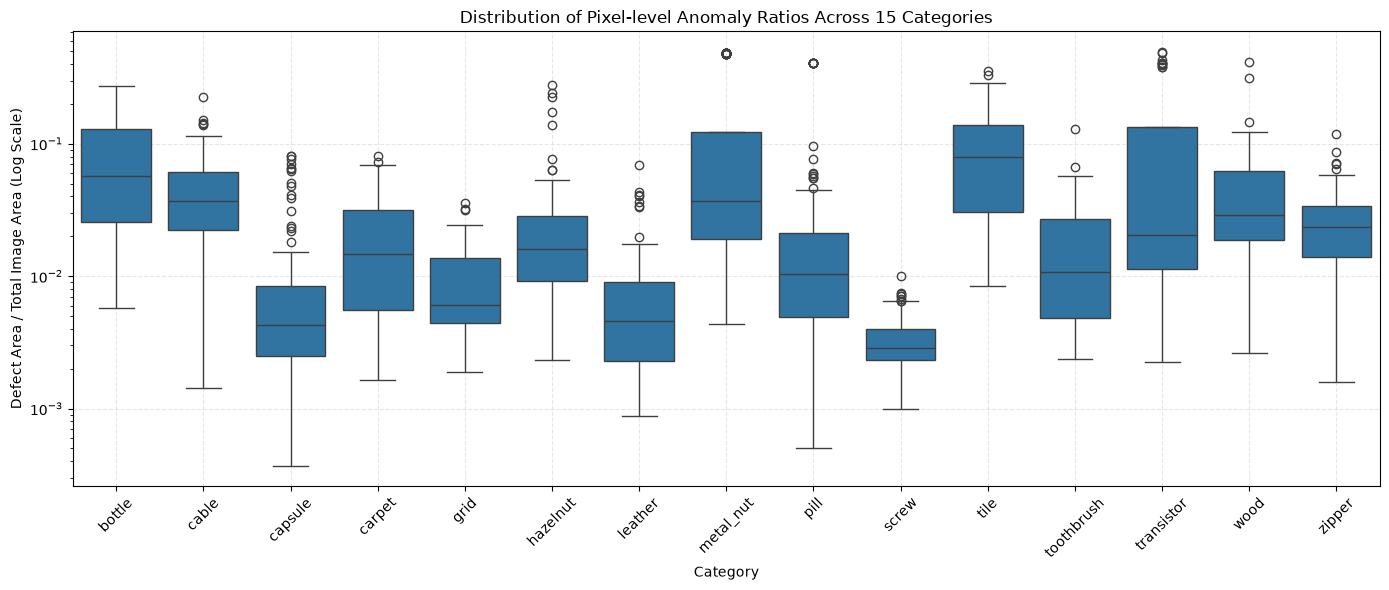

In [37]:
import seaborn as sns

df_ratios = pd.DataFrame(all_ratios)

plt.figure(figsize=(14, 6))
sns.boxplot(x="Category", y="Ratio", data=df_ratios)
plt.yscale("log")
plt.ylabel("Defect Area / Total Image Area (Log Scale)")
plt.xlabel("Category")
plt.title("Distribution of Pixel-level Anomaly Ratios Across 15 Categories")
plt.xticks(rotation=45)
plt.grid(True, ls="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# Load the summary benchmark score to ground our simulation
BENCHMARK_PATH = Path("../../data/external/aupimo_benchmarks/patchcore_wr50/mvtec/bottle/aupr.json")
data = pd.read_json(BENCHMARK_PATH, typ="series")
display(data)

target_aupr = data.get("value")
print(f"Target AUPR from benchmark curves: {target_aupr:.4f}")

value    0.757542
dtype: float64

Target AUPR from benchmark curves: 0.7575


Since we only have a single AUPR value for the PatchCore WR50 model, we will try to find a possible precision-recall curve with the same area under the curve.

The Recall follows a standard logistic sigmoid function:

$$R(x) = \frac{1}{1 + e^{-k_r(x - x_{r0})}}$$

The Precision follows a scaled and offset logistic sigmoid function:

$$P(x) = \frac{A}{1 + e^{-k_p(x - x_{p0})}} + \text{offset}$$

**For Recall:** When the threshold $x$ equals the midpoint $x_{r0}$, the exponent becomes $0$, making $e^0 = 1$. The denominator becomes $1 + 1 = 2$, yielding $R(x_{r0}) = 0.5$.

**For Precision:** When the threshold $x$ equals the midpoint $x_{p0} = 0.36$ (empirically tested), the exponent becomes $0$, making $e^0 = 1$. The denominator becomes $1 + 1 = 2$. With an amplitude $A = 0.95$ and a baseline offset of $0.03$, the unclipped function simplifies to $\frac{0.95}{2} + 0.03 = 0.505$.

**Sigmoid Midpoints ($x_{r0} = 0.5$ and $x_{p0} = 0.36$):** Selected to represent the physical behavior of the metrics. Recall stays high until the threshold hits the center of the defect distribution ($0.5$). Precision rises much earlier (midpoint at $0.36$) because normal background pixels (which constitute False Positives) are cleared out very rapidly at low thresholds.

**Threshold Range ($0$ to $1$ with a step of $0.005$)**: Anomaly localization models (like PatchCore) typically yield continuous anomaly score maps whose pixel maximums scale between $0$ and $1$.


**Slope Parameters ($k_r = -10.0$ and $k_p = 12.5$)**: Scale the rate of growth/decline so the resulting curves are smooth and match the target benchmark AUPR.


**Offsets and Clipping (`0.03`, `0.05`, `0.98`)**: A precision floor of `0.05` accounts for background sensor noise (false positives at low thresholds), while a ceiling of $0.95+0.03=0.98$ acknowledges that perfect $100\%$ precision is rarely achieved in noisy industrial environments.

In [87]:

# Threshold settings
thresh_start = 0.0
thresh_end = 1.0
thresh_step = 0.005
thresholds = np.arange(thresh_start, thresh_end + thresh_step, thresh_step)

# Recall parameters (Logistic Sigmoid)
recall_k = -10.0      # Slope parameter (negative because Recall decreases)
recall_x0 = 0.5       # Midpoint (inflection point)
recalls = 1.0 / (1.0 + np.exp(-recall_k * (thresholds - recall_x0)))

# Precision parameters (Logistic Sigmoid with scale and offset)
prec_amplitude = 0.95  # Scaling factor
prec_x0 = 0.36         # Midpoint (inflection point)
prec_k = 12.5          # Slope parameter (positive - Precision increases)
prec_offset = 0.03     # Baseline offset
prec_floor = 0.05      # Minimum precision clip limit
prec_ceiling = 0.98    # Maximum precision clip limit

precisions = prec_amplitude / (1.0 + np.exp(-prec_k * (thresholds - prec_x0))) + prec_offset

# Apply clipping boundaries to represent physical constraints
precisions = np.clip(precisions, prec_floor, prec_ceiling)

# Calculate simulated AUPR to verify realism
simulated_aupr = np.trapezoid(precisions[::-1], recalls[::-1])
print(f"Simulated Curve AUPR: {simulated_aupr:.4f} (Target: {target_aupr:.4f})")


Simulated Curve AUPR: 0.7254 (Target: 0.7575)


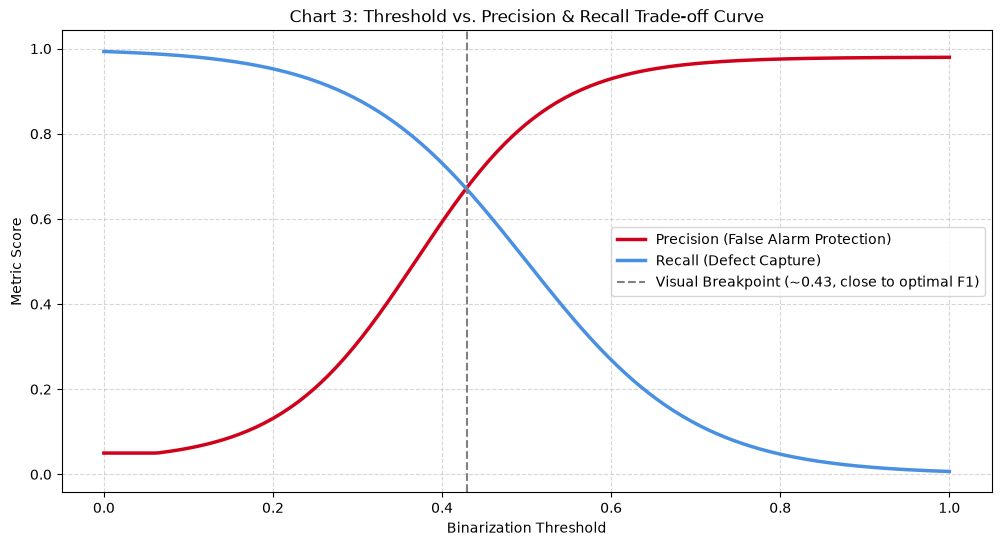

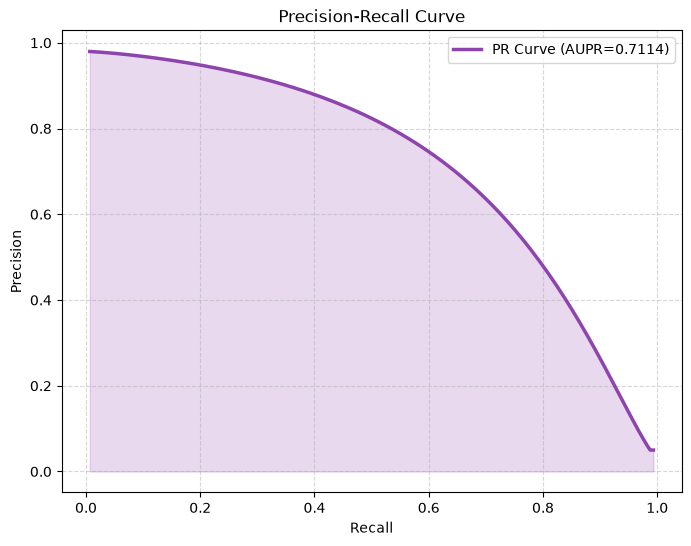

In [49]:

plt.figure(figsize=(12, 6))
plt.plot(thresholds, precisions, label="Precision (False Alarm Protection)", color="#D0021B", lw=2.5)
plt.plot(thresholds, recalls, label="Recall (Defect Capture)", color="#4A90E2", lw=2.5)
plt.axvline(0.43, color="gray", linestyle="--", label="Visual Breakpoint (~0.43, close to optimal F1)")

plt.xlabel("Binarization Threshold")
plt.ylabel("Metric Score")
plt.title("Chart 3: Threshold vs. Precision & Recall Trade-off Curve")
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label=f"PR Curve (AUPR={simulated_aupr:.4f})", color="#8E44AD", lw=2.5)
plt.fill_between(recalls, precisions, alpha=0.2, color="#8E44AD")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.show()


In [88]:

def f_beta(p, r, beta):
    return (1 + beta**2) * (p * r) / ((beta**2 * p) + r)

f1 = f_beta(precisions, recalls, 1.0)
f2 = f_beta(precisions, recalls, 2.0)
f05 = f_beta(precisions, recalls, 0.5)

idx_f1 = np.argmax(f1)
idx_f2 = np.argmax(f2)
idx_f05 = np.argmax(f05)

print(f"Optimal F1 Threshold: {thresholds[idx_f1]:.2f} (Score: {f1[idx_f1]:.4f})")
print(f"Optimal F2 (Recall-heavy) Threshold: {thresholds[idx_f2]:.2f} (Score: {f2[idx_f2]:.4f})")
print(f"Optimal F0.5 (Precision-heavy) Threshold: {thresholds[idx_f05]:.2f} (Score: {f05[idx_f05]:.4f})")

Optimal F1 Threshold: 0.43 (Score: 0.6840)
Optimal F2 (Recall-heavy) Threshold: 0.37 (Score: 0.7183)
Optimal F0.5 (Precision-heavy) Threshold: 0.49 (Score: 0.7396)


# Precision-Recall Curve on Real Data

The data have been computed using [Anomalib](https://github.com/open-edge-platform/anomalib) and the bottle dataset from [MVTecAD](../../data/raw/mvtec_ad) - the details are present in this [Notebook](precision_recall_threshold.ipynb).

In [89]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# Define the path to your exported PR curve coordinates
REAL_DATA_PATH = Path("../../data/external/aupimo_benchmarks/patchcore_wr50/mvtec/bottle/real_pr_curve.npz")

data = np.load(REAL_DATA_PATH)
# Note: Anomalib PR curve outputs precision and recall with length N+1 (last element 1.0 and 0.0 respectively)
# and thresholds with length N. We match lengths accordingly.
precisions = data["precision"]
recalls = data["recall"]
thresholds = data["thresholds"]

# Align shapes if metrics returned boundary values
if len(precisions) == len(thresholds) + 1:
    precisions = precisions[:-1]
    recalls = recalls[:-1]
    
print(f"Successfully loaded {len(thresholds)} real datapoints.")
is_real = True

Successfully loaded 3793850 real datapoints.


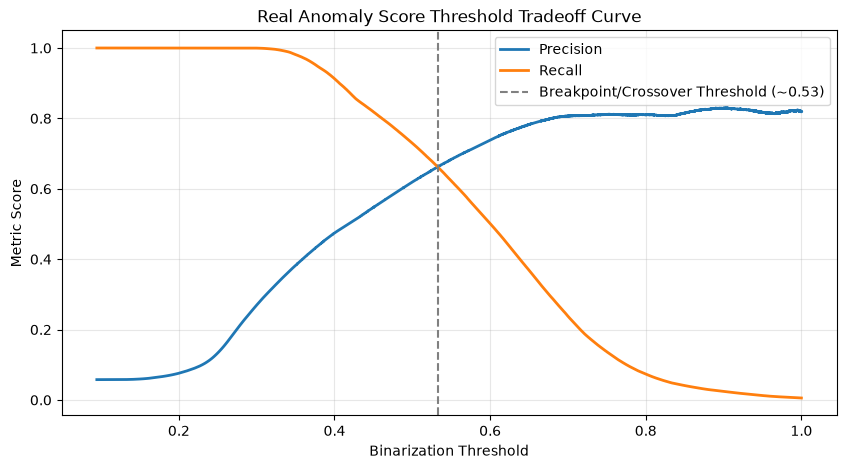

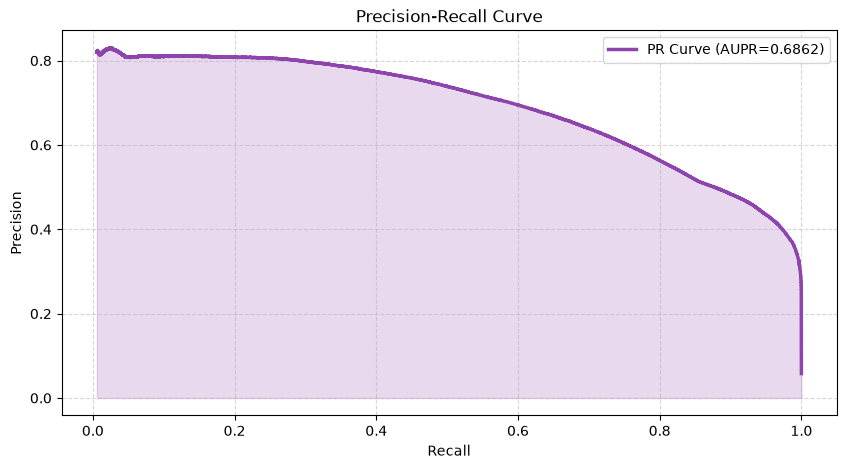

In [3]:
# Locate the metric crossover point (where Precision ~= Recall)
diff = np.abs(precisions - recalls)
crossover_idx = np.argmin(diff)
t_crossover = thresholds[crossover_idx]

integrated_aupr = np.trapezoid(precisions[::-1], recalls[::-1])

plt.figure(figsize=(10, 5), dpi=100)
plt.plot(thresholds, precisions, label='Precision', color='#1f77b4', linewidth=2)
plt.plot(thresholds, recalls, label='Recall', color='#ff7f0e', linewidth=2)
plt.axvline(x=t_crossover, color="gray", linestyle="--", label=f"Breakpoint/Crossover Threshold (~{t_crossover:.2f})")

plt.title("Real Anomaly Score Threshold Tradeoff Curve" if is_real else "Simulated Anomaly Score Threshold Tradeoff Curve (Demo Mode)")
plt.xlabel("Binarization Threshold")
plt.ylabel("Metric Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(recalls, precisions, label=f"PR Curve (AUPR={integrated_aupr:.4f})", color="#8E44AD", lw=2.5)
plt.fill_between(recalls, precisions, alpha=0.2, color="#8E44AD")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.show()

The precision-recall curve's precision collapse is simply due to the extremely small threshold which identifies every kind of noise as anomaly, massive increase of FPs.

In [3]:
def f_beta(p, r, beta):
    return (1 + beta**2) * (p * r) / ((beta**2 * p) + r)

f1 = f_beta(precisions, recalls, 1.0)
f2 = f_beta(precisions, recalls, 2.0)
f05 = f_beta(precisions, recalls, 0.5)

idx_f1 = np.argmax(f1)
idx_f2 = np.argmax(f2)
idx_f05 = np.argmax(f05)

print(f"Optimal F1 Threshold: {thresholds[idx_f1]:.4f} (Score: {f1[idx_f1]:.4f})")
print(f"Optimal F2 (Recall-heavy) Threshold: {thresholds[idx_f2]:.4f} (Score: {f2[idx_f2]:.4f})")
print(f"Optimal F0.5 (Precision-heavy) Threshold: {thresholds[idx_f05]:.4f} (Score: {f05[idx_f05]:.4f})")

Optimal F1 Threshold: 0.5000 (Score: 0.6699)
Optimal F2 (Recall-heavy) Threshold: 0.3908 (Score: 0.7716)
Optimal F0.5 (Precision-heavy) Threshold: 0.5830 (Score: 0.6759)


# Conclusion

The area under precision-recall curve is smaller than in the given benchmark [](../../data/external/aupimo_benchmarks/patchcore_wr50/mvtec/bottle/aupr.json) which will be mostly due to the usage of a smaller Patchcore model. Our model performed about $7\%$ worse
In a real application this would mean, that our model either causes more false alarms (recall-heavy) or miss more defects (precision-heavy) resulting in a general worse prediction. We do not look at othe scores like accuracy here due to the unbalanced nature of the dataset.